# M3 FFT + reverse-L advection initialization benchmark (083126)

고정 baseline은 **M0 zero**와 **M3 empirical $\tau=1$**이다. 이 실험은 정규격자의 장점을 두 단계에서 이용한다: (1) spatial binning 없이 masked FFT로 M3 semivariogram을 정확하고 빠르게 계산하고, (2) M3 seed에서 출발해 regular-grid reverse-L Vecchia likelihood를 advection-only로 5회 평가하여 짧게 보정한다. 선택된 advection으로 corridor geometry를 한 번 만든 뒤, 최종 7-parameter fit 동안 corridor는 다시 만들지 않는다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
OUT = REPO / 'outputs/summer_26/synthetic_m3_reverse_l_initialization_benchmark_corridor432_083126'
init = pd.read_csv(OUT / 'initializer_results.csv')
init_summary = pd.read_csv(OUT / 'initializer_summary.csv')
equiv = pd.read_csv(OUT / 'fft_equivalence.csv')
reverse_l = pd.read_csv(OUT / 'reverse_l_diagnostics.csv')
full = pd.read_csv(OUT / 'full_fit_results.csv')
full_summary = pd.read_csv(OUT / 'full_fit_summary.csv')
runtime = json.loads((OUT / 'total_runtime.json').read_text())
assert init['status'].eq('ok').all()
assert full['status'].eq('ok').all()
assert equiv['same_seed'].all() and equiv['max_abs_smoothed_diff'].max() < 1e-8
print(f"initializer rows/status: {len(init)} / all ok")
print(f"full-fit rows/status: {len(full)} / all ok")
print(f"benchmark wall time: {runtime['benchmark_wall_s']:.2f} s ({runtime['benchmark_wall_minutes']:.2f} min)")

initializer rows/status: 21 / all ok
full-fit rows/status: 21 / all ok
benchmark wall time: 197.78 s (3.30 min)


## M3와 exact masked FFT

시간 간격 $\tau=1$인 연속 영상 $Z_t, Z_{t+1}$에서 공간 격자 offset $h=(h_{lat},h_{lon})$마다

$$\widehat\gamma_1(h)=\frac{1}{2N(h)}\sum_{t=1}^{7}\sum_{s\in\mathcal V_t(h)}\{Z_t(s)-Z_{t+1}(s+h)\}^2$$

를 계산하고 가장 작은 위치를 advection seed로 쓴다. regular grid이므로 거리 binning은 전혀 필요 없다. 결측 mask를 $M_A,M_B$, 결측을 0으로 채운 영상을 $A,B$라 하면 각 offset의 제곱차 합은 correlation 네 번으로 정확히 계산된다.

$$S(h)=\operatorname{corr}(M_B,A^2)+\operatorname{corr}(B^2,M_A)-2\operatorname{corr}(B,A),$$
$$N(h)=\operatorname{corr}(M_B,M_A),\qquad \widehat\gamma_1(h)=S(h)/(2N(h)).$$

따라서 FFT 버전은 근사가 아니라 기존 loop M3와 같은 pair-count weighted surface이다. `M3_fft_subgrid`는 grid minimum 주위 3×3 값에 양의 정부호 quadratic을 적합하고, minimum이 cell 내부에 있을 때만 fractional-grid correction을 허용한다. `trimmed` 버전은 7개 시간쌍 surface를 scale-normalize한 뒤 양 끝 하나씩 제외해 일시적 이상치에 덜 민감하게 만든다.

In [2]:
display(equiv.style.format({
    'max_abs_gamma_diff': '{:.2e}',
    'max_abs_smoothed_diff': '{:.2e}',
    'max_abs_count_diff': '{:.0f}',
}))
m3_loop_s = init_summary.loc[init_summary.method.eq('M3_empirical_loop'), 'mean_seed_s'].iat[0]
m3_fft_s = init_summary.loc[init_summary.method.eq('M3_fft_exact'), 'mean_seed_s'].iat[0]
print(f'FFT speed-up over loop M3: {m3_loop_s / m3_fft_s:.1f}x')

,year,day_idx,day,max_abs_gamma_diff,max_abs_smoothed_diff,max_abs_count_diff,same_seed
0,2023,0,2023-07-01,5.33e-15,5.33e-15,0,True
1,2023,1,2023-07-02,7.11e-15,5.33e-15,0,True
2,2023,2,2023-07-03,5.33e-15,5.33e-15,0,True


FFT speed-up over loop M3: 15.1x


## Reverse-L 결합 방식

Reverse-L은 regular grid ordering에서 현재 위치의 위쪽/오른쪽 이웃과 이전 두 시간 lag의 local stencil을 conditioning set으로 사용한다. 이 실험에서는 M3의 robust sub-grid seed에서 시작해 **nuisance parameter는 truth에 고정하고 advection 두 개만**, L-BFGS closure 최대 5회로 보정했다. 이렇게 해야 짧은 initializer 단계에서 range-time, spatial range, nugget이 advection과 서로 대신 움직이는 confounding을 막을 수 있다.

- `s2`: 행과 열을 하나씩 건너뛴 23×32 regular subgrid, 시간당 약 736점
- `full`: 45×63 grid, 시간당 약 2835점
- geometry: above=2, right columns=3, per-lag=14, temporal lags=2
- reverse-L은 initializer 전용이다. 최종 비교는 모든 방법에 동일한 lag-432 directional corridor와 동일한 7-parameter budget을 쓴다.

In [3]:
cols = ['method', 'mean_seed_s', 'mean_seed_error', 'median_seed_error',
        'max_seed_error', 'mean_angle_error_deg', 'correct_quadrant_rate',
        'mean_closure_calls']
table = init_summary[cols].copy().sort_values('mean_seed_error')
display(table.style.format({
    'mean_seed_s': '{:.4f}', 'mean_seed_error': '{:.6f}',
    'median_seed_error': '{:.6f}', 'max_seed_error': '{:.6f}',
    'mean_angle_error_deg': '{:.3f}', 'correct_quadrant_rate': '{:.0%}',
    'mean_closure_calls': '{:.1f}',
}))
baseline_err = init_summary.loc[init_summary.method.eq('M3_empirical_loop'), 'mean_seed_error'].iat[0]
s2_err = init_summary.loc[init_summary.method.eq('M3_reverseL_s2_refine5'), 'mean_seed_error'].iat[0]
print(f'Reverse-L s2 mean-error reduction vs M3: {(1-s2_err/baseline_err):.1%}')

,method,mean_seed_s,mean_seed_error,median_seed_error,max_seed_error,mean_angle_error_deg,correct_quadrant_rate,mean_closure_calls
6,M3_reverseL_s2_refine5,1.3450,0.007500,0.004670,0.014419,1.094,100%,5.0
5,M3_reverseL_full_refine5,4.9258,0.008479,0.002263,0.020975,1.156,100%,5.0
3,M3_fft_subgrid,0.0064,0.012582,0.012990,0.014496,1.696,100%,0.0
4,M3_fft_trimmed_subgrid,0.0061,0.012622,0.013720,0.015400,1.091,100%,0.0
1,M3_empirical_loop,0.1278,0.013601,0.013601,0.013601,3.166,100%,0.0
2,M3_fft_exact,0.0085,0.013601,0.013601,0.013601,3.166,100%,0.0
0,M0_zero,0.0000,0.215407,0.215407,0.215407,nan,0%,0.0


Reverse-L s2 mean-error reduction vs M3: 44.9%


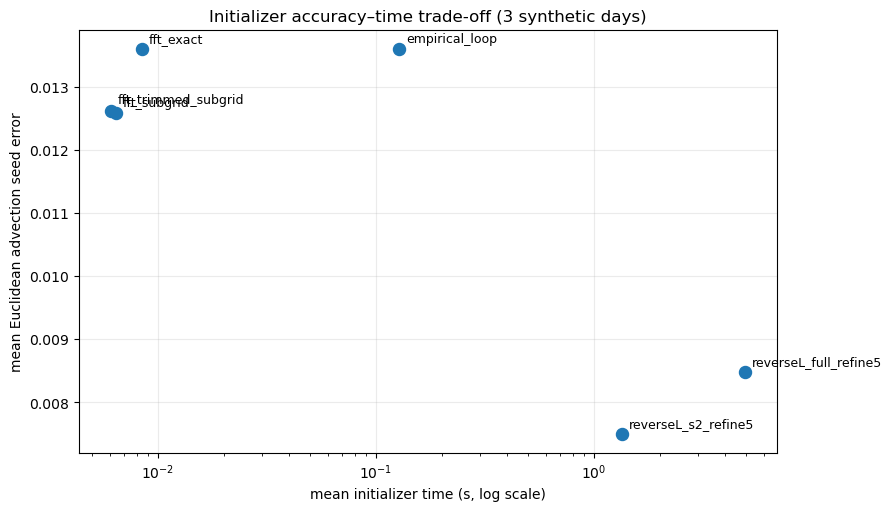

In [4]:
plot_df = init_summary.query("method != 'M0_zero'").copy()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(plot_df.mean_seed_s, plot_df.mean_seed_error, s=75)
for row in plot_df.itertuples():
    ax.annotate(row.method.replace('M3_', ''), (row.mean_seed_s, row.mean_seed_error),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('mean initializer time (s, log scale)')
ax.set_ylabel('mean Euclidean advection seed error')
ax.set_title('Initializer accuracy–time trade-off (3 synthetic days)')
ax.grid(alpha=.25)
plt.show()

In [5]:
per_day = init.pivot(index='day', columns='method', values='seed_error_euclid')
display(per_day.style.format('{:.6f}').highlight_min(axis=1, color='#c8e6c9'))

method,M0_zero,M3_empirical_loop,M3_fft_exact,M3_fft_subgrid,M3_fft_trimmed_subgrid,M3_reverseL_full_refine5,M3_reverseL_s2_refine5
day,,,,,,,
2023-07-01,0.215407,0.013601,0.013601,0.014496,0.013720,0.002263,0.003410
2023-07-02,0.215407,0.013601,0.013601,0.012990,0.015400,0.020975,0.014419
2023-07-03,0.215407,0.013601,0.013601,0.010259,0.008747,0.002200,0.004670


In [6]:
rl_cols = ['day', 'method', 'reverse_l_spatial_stride', 'reverse_l_points_per_hour',
           'reverse_l_n_tails', 'reverse_l_precompute_s', 'reverse_l_refine_s',
           'reverse_l_closure_calls', 'reverse_l_nll']
display(reverse_l[rl_cols].style.format({
    'reverse_l_precompute_s': '{:.4f}', 'reverse_l_refine_s': '{:.4f}',
    'reverse_l_nll': '{:.6f}',
}))

,day,method,reverse_l_spatial_stride,reverse_l_points_per_hour,reverse_l_n_tails,reverse_l_precompute_s,reverse_l_refine_s,reverse_l_closure_calls,reverse_l_nll
0,2023-07-01,M3_reverseL_s2_refine5,2,736,5793,0.0523,1.2313,5,1.317998
1,2023-07-01,M3_reverseL_full_refine5,1,2835,22309,0.2183,4.7210,5,1.128091
2,2023-07-02,M3_reverseL_s2_refine5,2,736,5800,0.0483,1.1749,5,1.337300
3,2023-07-02,M3_reverseL_full_refine5,1,2835,22311,0.2192,4.6234,5,1.134776
4,2023-07-03,M3_reverseL_s2_refine5,2,736,5803,0.0498,1.4604,5,1.322743
5,2023-07-03,M3_reverseL_full_refine5,1,2835,22351,0.2227,4.7544,5,1.138382


## 최종 7-parameter fit

각 initializer가 만든 advection으로 corridor geometry를 한 번 고정한다. 그 후 모든 covariance parameter를 동일한 nuisance start와 동일한 `outer=1, max_eval=10` budget으로 적합한다. `end_to_end_s = seed_total_s + final_total_s`이다. seed가 서로 다른 corridor geometry를 만들기 때문에, final NLL과 final advection error가 initializer의 downstream 효과를 나타낸다.

In [7]:
full_cols = ['method', 'mean_final_nll', 'mean_final_advection_error',
             'mean_final_rmsre_7param', 'mean_final_fit_s', 'mean_end_to_end_s']
display(full_summary[full_cols].sort_values('mean_final_advection_error').style.format({
    'mean_final_nll': '{:.6f}', 'mean_final_advection_error': '{:.6f}',
    'mean_final_rmsre_7param': '{:.6f}', 'mean_final_fit_s': '{:.3f}',
    'mean_end_to_end_s': '{:.3f}',
}))
per_day_final = full.pivot(index='day', columns='method', values='final_seed_error_euclid')
display(per_day_final.style.format('{:.6f}').highlight_min(axis=1, color='#c8e6c9'))

,method,mean_final_nll,mean_final_advection_error,mean_final_rmsre_7param,mean_final_fit_s,mean_end_to_end_s
3,M3_fft_subgrid,1.128879,0.005648,0.032087,8.101,8.107
6,M3_reverseL_s2_refine5,1.128757,0.006107,0.035168,8.252,9.597
5,M3_reverseL_full_refine5,1.128690,0.006391,0.028416,8.244,13.170
4,M3_fft_trimmed_subgrid,1.128760,0.006736,0.029678,8.119,8.125
1,M3_empirical_loop,1.128689,0.006811,0.032373,7.932,8.060
2,M3_fft_exact,1.128689,0.006811,0.032373,8.560,8.569
0,M0_zero,1.134876,0.008782,0.030814,7.868,7.868


method,M0_zero,M3_empirical_loop,M3_fft_exact,M3_fft_subgrid,M3_fft_trimmed_subgrid,M3_reverseL_full_refine5,M3_reverseL_s2_refine5
day,,,,,,,
2023-07-01,0.012565,0.004733,0.004733,0.004430,0.004566,0.004523,0.003431
2023-07-02,0.007602,0.012408,0.012408,0.009464,0.012517,0.011508,0.011776
2023-07-03,0.006180,0.003293,0.003293,0.003050,0.003127,0.003141,0.003114


## 이번 3일 실험의 결론

1. **M3 loop는 M3 FFT exact로 교체 가능하다.** seed가 3일 모두 동일하고 smoothed surface 차이는 $7\times10^{-15}$ 이하인 반면 initializer는 약 15배 빨라졌다.
2. **무료에 가까운 개선은 FFT sub-grid이다.** 평균 seed error 0.01258로 M3의 0.01360보다 작고 약 0.006초다. trimmed sub-grid는 평균 방향각은 더 좋지만 vector error와 downstream 결과에서 일관된 우위는 없었다.
3. **reverse-L 후보 중 stride-2가 낫다.** s2는 평균 seed error 0.00750, full은 0.00848이다. full-grid는 7월 2일에 seed를 악화시켜, 더 많은 점이 항상 더 robust한 초기값을 뜻하지 않았다. s2는 full보다 약 3.7배 빠르다.
4. **추천 default:** 시간이 극도로 중요하면 `M3_fft_subgrid`; 약 1.35초를 허용해 더 robust한 seed를 원하면 `M3_reverseL_s2_refine5`. full reverse-L은 기본값으로 권하지 않는다.
5. 최종 fit의 평균 advection error는 FFT sub-grid가 0.00565로 가장 작았고 reverse-L s2는 0.00611이었다. 즉 initializer seed 자체는 reverse-L s2가 가장 좋지만, 짧은 full-fit 이후 순위는 완전히 보존되지 않는다. 현재 결론은 동일 truth의 3일에 근거하므로, 여러 advection speed/direction과 nuisance misspecification에서 확인해야 한다.